# EE 513 Smoke Test

**Due before Thursday's lecture.** Run every cell. If anything reports `FAIL`, fix it now rather than in week 3.

This notebook checks five things:

1. Your Python is new enough.
2. The packages the course uses are installed and importable.
3. OpenCV 5 is present, and you know what moved in it.
4. You can read a raw file from a camera.
5. Git is configured and you can make a commit.

Nothing here needs a GPU. If a check fails, the message tells you what to do. Bring questions to Thursday.

In [1]:
# A tiny pass/fail collector used by the rest of the notebook.
import sys, platform, textwrap

RESULTS = []

def check(name, ok, detail="", fix=""):
    RESULTS.append((name, bool(ok), detail, fix))
    mark = "PASS" if ok else "FAIL"
    print(f"[{mark}] {name}" + (f"  {detail}" if detail else ""))
    if not ok and fix:
        print(textwrap.indent(textwrap.fill(f"Fix: {fix}", 86), "       "))
    return ok

print("Python  ", sys.version.split()[0])
print("Platform", platform.platform())
print("Executable", sys.executable)

Python   3.12.12
Platform macOS-26.5.1-arm64-arm-64bit
Executable /Users/mcnames/Library/CloudStorage/Dropbox/Courses/.venv/bin/python


In [2]:
# 1. Python version. The course targets 3.12; 3.10 or newer is fine.
major, minor = sys.version_info[:2]
check(
    "Python 3.10 or newer",
    (major, minor) >= (3, 10),
    f"found {major}.{minor}",
    "You should not see this if you started the notebook with `uv run jupyter lab` "
    "from the course folder. Check that pyproject.toml and uv.lock are in that "
    "folder, then run `uv sync` again.",
)

[PASS] Python 3.10 or newer  found 3.12


True

## 2. Packages

`REQUIRED` is what the first half of the term uses. `LATER` is not used until week 6, but the course environment installs it now, so all of these should report a version. A version number means the import worked; anything genuinely missing is listed separately as `missing:` and means `uv sync` did not finish.

In [3]:
import importlib

REQUIRED = ["numpy", "scipy", "matplotlib", "cv2", "rawpy", "imageio", "skimage"]
LATER    = ["torch", "colour", "gradio"]

def version_of(mod):
    for attr in ("__version__", "version", "VERSION"):
        v = getattr(mod, attr, None)
        if isinstance(v, str):
            return v
    return "?"

def try_import(names, required):
    found = {}
    for name in names:
        try:
            mod = importlib.import_module(name)
            found[name] = version_of(mod)
        except Exception as exc:
            found[name] = None
            if required:
                check(f"import {name}", False, "",
                      f"{PIP_NAME.get(name, name)} is missing. Run `uv sync` in the course "
                      f"folder; do not pip install it.   ({type(exc).__name__})")
    return found

# Distribution names, for the message only. Do not pip install these by hand: the
# environment comes from uv.lock, and installing plain opencv-python on top of
# opencv-contrib-python breaks cv2 in a way that is hard to diagnose.
PIP_NAME = {"cv2": "opencv-contrib-python", "skimage": "scikit-image",
            "colour": "colour-science"}

req = try_import(REQUIRED, required=True)
check("all required packages import", all(v is not None for v in req.values()),
      ", ".join(f"{k} {v}" for k, v in req.items() if v))

later = try_import(LATER, required=False)
missing_later = [k for k, v in later.items() if v is None]
print()
print("Not used until week 6, but the course environment installs them now:",
      ", ".join(f"{k} {v}" for k, v in later.items() if v) or "(none installed)")
if missing_later:
    print("  missing:", ", ".join(missing_later), "- run `uv sync` again.")

[PASS] all required packages import  numpy 2.5.3, scipy 1.18.1, matplotlib 3.11.2, cv2 5.0.0, rawpy 0.27.1, imageio 2.38.0, skimage 0.26.0

Not used until week 6, but the course environment installs them now: torch 2.14.0, colour 0.4.7, gradio 6.29.0


## 3. OpenCV 5

OpenCV 5.0 reorganized its C++ modules in June 2026, and a few things left the main package. Two consequences for you:

- Most tutorials and Stack Overflow answers you find were written for OpenCV 4. Check the version before trusting a snippet.
- Haar cascades (`CascadeClassifier`) and `HOGDescriptor` are no longer in the main wheel. If a tutorial uses them, it is pre-2026.

The Python API itself is still flat: you call `cv2.calibrateCamera`, not `cv2.calib.calibrateCamera`. The C++ reorganization does not show up in the Python names.

In [4]:
import cv2

check("OpenCV major version is 5", cv2.__version__.startswith("5"),
      f"found {cv2.__version__}",
      "Run `uv sync` in the course folder. Version 4 will work for most of the term, "
      "but the demosaicing and calibration examples assume 5.")

# This course needs opencv-CONTRIB-python, not plain opencv-python. In 5.0 the plain
# package dropped HOG, Haar cascades, AKAZE, KAZE and BRISK entirely; contrib returns
# the first two to the top level and moves the detectors into cv2.xfeatures2d.
check("you have the contrib build, not plain opencv-python",
      hasattr(cv2, "xfeatures2d"),
      "cv2.xfeatures2d present" if hasattr(cv2, "xfeatures2d") else "cv2.xfeatures2d missing",
      "You are on plain opencv-python. Delete the .venv folder and run `uv sync` again, "
      "which installs opencv-contrib-python. Never install both packages.")

# Things this course uses, all still at the top level of cv2 in version 5.
NEEDED = ["calibrateCamera", "findChessboardCorners", "undistort",
          "demosaicing", "cvtColor", "bilateralFilter", "SIFT_create"]
absent = [fn for fn in NEEDED if not hasattr(cv2, fn)]
check("functions this course uses are present", not absent,
      f"{len(NEEDED) - len(absent)} of {len(NEEDED)}",
      f"missing: {absent}. You may be on a headless or minimal build.")

# What 5.0 rearranged. With the contrib build, HOG and Haar cascades are back at the
# top level; the classical feature detectors are not, and live under cv2.xfeatures2d.
print()
for fn in ["CascadeClassifier", "HOGDescriptor"]:
    print(f"  cv2.{fn:20} {'present' if hasattr(cv2, fn) else 'MISSING'}  (contrib restores this)")
for fn in ["AKAZE_create", "KAZE_create", "BRISK_create"]:
    top = hasattr(cv2, fn)
    sub = hasattr(getattr(cv2, "xfeatures2d", object()), fn)
    print(f"  cv2.{fn:20} {'present' if top else 'moved'}"
          f"   cv2.xfeatures2d.{fn}: {'present' if sub else 'missing'}")
print("\nIn OpenCV 5 you call cv2.xfeatures2d.AKAZE_create(), not cv2.AKAZE_create().")
print("If a tutorial calls the second form, it predates 2026.")

[PASS] OpenCV major version is 5  found 5.0.0
[PASS] you have the contrib build, not plain opencv-python  cv2.xfeatures2d present
[PASS] functions this course uses are present  7 of 7

  cv2.CascadeClassifier    present  (contrib restores this)
  cv2.HOGDescriptor        present  (contrib restores this)
  cv2.AKAZE_create         moved   cv2.xfeatures2d.AKAZE_create: present
  cv2.KAZE_create          moved   cv2.xfeatures2d.KAZE_create: present
  cv2.BRISK_create         moved   cv2.xfeatures2d.BRISK_create: present

In OpenCV 5 you call cv2.xfeatures2d.AKAZE_create(), not cv2.AKAZE_create().
If a tutorial calls the second form, it predates 2026.


## 4. Read a raw file

Project 1 starts in week 1 and needs raw captures, so this is the check that matters most.

Put one raw file from your camera in the `Images/` folder beside the slides, or anywhere below this notebook, and rerun. Common extensions: `.dng` (iPhone ProRAW, Android, Lightroom), `.arw` (Sony), `.cr2` or `.cr3` (Canon), `.nef` (Nikon), `.raf` (Fuji), `.orf` (Olympus).

If you cannot produce one yet, this check will say so and the rest of the notebook still runs. Come see me and borrow a Raspberry Pi HQ camera kit.

In [5]:
from pathlib import Path

RAW_SUFFIXES = {".dng", ".arw", ".cr2", ".cr3", ".nef", ".raf", ".orf", ".rw2", ".pef", ".srw"}

def find_images_dir(start=None):
    """Walk up from the notebook looking for a directory named Images."""
    here = (start or Path.cwd()).resolve()
    for parent in [here, *here.parents]:
        candidate = parent / "Images"
        if candidate.is_dir():
            return candidate
    return None

def find_raw_files():
    roots = [p for p in (find_images_dir(), Path.cwd(), Path.home() / "Downloads") if p]
    seen, found = set(), []
    for root in roots:
        if root in seen:
            continue
        seen.add(root)
        for path in sorted(root.rglob("*")):
            if path.suffix.lower() in RAW_SUFFIXES and path.is_file():
                found.append(path)
    return found

IMAGES_DIR = find_images_dir()
print("Images directory:", IMAGES_DIR or "not found")

raws = find_raw_files()
if raws:
    print(f"Found {len(raws)} raw file(s). Using: {raws[0].name}")
else:
    print("No raw files found yet.")

Images directory: /Users/mcnames/Library/CloudStorage/Dropbox/Courses/EE 513 IP/Slides/Images
Found 1 raw file(s). Using: 629B07DB-3DEE-4FD7-91A5-46EB54BDCC4A.DNG


In [6]:
import rawpy
import numpy as np

RAW_PATH = raws[0] if raws else None

if RAW_PATH is None:
    check("read a raw file", False, "no raw file found",
          "Capture one raw photo and put it in the Images/ folder beside the slides, "
          "then rerun this cell. This is the one prerequisite that cannot wait.")
else:
    with rawpy.imread(str(RAW_PATH)) as raw:
        bayer = raw.raw_image_visible.copy()
        pattern = raw.color_desc.decode() if isinstance(raw.color_desc, bytes) else str(raw.color_desc)
        black = np.atleast_1d(raw.black_level_per_channel)
        white = raw.white_level
        wb = np.array(raw.camera_whitebalance, dtype=float)

    ok = check("read a raw file", bayer.size > 0, f"{RAW_PATH.name}")
    print()
    print(f"  sensor array      {bayer.shape[1]} x {bayer.shape[0]} px "
          f"({bayer.size / 1e6:.1f} Mpx), dtype {bayer.dtype}")
    print(f"  color filter      {pattern}")
    print(f"  black level       {black.tolist()}")
    print(f"  white level       {white}  ->  about {np.log2(white - black.mean()):.1f} bits of range")
    print(f"  camera white bal  {np.round(wb, 3).tolist()}")
    print(f"  measured range    {bayer.min()} to {bayer.max()}")
    print()
    print("  Every pixel above measured exactly one color. The other two were interpolated")
    print("  by the camera. That interpolation is Project 2.")

[PASS] read a raw file  629B07DB-3DEE-4FD7-91A5-46EB54BDCC4A.DNG

  sensor array      4032 x 3024 px (12.2 Mpx), dtype uint16
  color filter      RGBG
  black level       [528, 528, 528, 528]
  white level       4095  ->  about 11.8 bits of range
  camera white bal  [2.217, 1.0, 2.133, 0.0]
  measured range    524 to 3403

  Every pixel above measured exactly one color. The other two were interpolated
  by the camera. That interpolation is Project 2.


## 5. Prove the environment can do real work

Fill in the one missing function below. It is deliberately small: the point is that you can write array code without an assistant, because the exams are closed-book and closed-AI.

Convert an RGB image to grayscale using the Rec. 709 luma weights, **without** calling `cv2.cvtColor` or any library conversion.

$$Y = 0.2126\,R + 0.7152\,G + 0.0722\,B$$

[PASS] to_gray returns the right shape  (256, 256)
[PASS] to_gray weights sum to 1 on a neutral patch  a gray input must come out at the same level


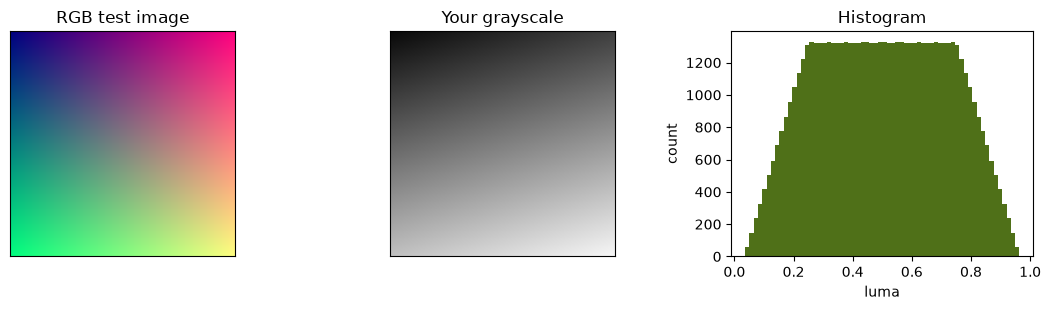

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def to_gray(rgb):
    """rgb: float array, shape (H, W, 3), values in [0, 1]. Returns (H, W) float."""
    # YOUR CODE HERE. One line is enough. Do not call a library conversion.
    return 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]

# A synthetic test image, so this cell runs whether or not you have a photo yet.
yy, xx = np.mgrid[0:256, 0:256] / 255.0
test = np.stack([xx, yy, 0.5 * np.ones_like(xx)], axis=-1)

gray = to_gray(test)
check("to_gray returns the right shape", gray.shape == test.shape[:2], str(gray.shape))
check("to_gray weights sum to 1 on a neutral patch",
      np.isclose(to_gray(np.full((1, 1, 3), 0.42))[0, 0], 0.42, atol=1e-6),
      "a gray input must come out at the same level")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
axes[0].imshow(test);            axes[0].set_title("RGB test image")
axes[1].imshow(gray, cmap="gray", vmin=0, vmax=1); axes[1].set_title("Your grayscale")
axes[2].hist(gray.ravel(), bins=64, color="#4f7018"); axes[2].set_title("Histogram")
axes[2].set_xlabel("luma"); axes[2].set_ylabel("count")
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Git

Every project in this course is a public GitHub repository with a real commit history. Run these in a terminal, not here:

```bash
git config --global user.name  "Your Name"
git config --global user.email "you@pdx.edu"

mkdir ee513-smoke-test && cd ee513-smoke-test
git init
cp /path/to/this/notebook .
git add .
git commit -m "EE 513 smoke test"
```

Then create an empty repository on GitHub and push it. The cell below only checks that git exists and knows who you are.

In [8]:
import shutil, subprocess

git = shutil.which("git")
check("git is installed", git is not None, git or "",
      "Install git: xcode-select --install on macOS, or your package manager on Linux.")

if git:
    def git_config(key):
        out = subprocess.run([git, "config", "--get", key], capture_output=True, text=True)
        return out.stdout.strip()

    name, email = git_config("user.name"), git_config("user.email")
    check("git user.name is set",  bool(name),  name,
          'git config --global user.name "Your Name"')
    check("git user.email is set", bool(email), email,
          'git config --global user.email "you@pdx.edu"')

[PASS] git is installed  /usr/bin/git
[PASS] git user.name is set  James McNames
[PASS] git user.email is set  james@mcnames.com


## Summary

In [9]:
passed = [r for r in RESULTS if r[1]]
failed = [r for r in RESULTS if not r[1]]

print(f"{len(passed)} passed, {len(failed)} failed\n")
if failed:
    print("Still to fix:")
    for name, _, detail, fix in failed:
        print(f"  - {name}" + (f" ({detail})" if detail else ""))
        if fix:
            print(f"      {fix}")
    print("\nIf you are stuck on any of these, email me before Thursday rather than guessing.")
else:
    print("Everything passed. You are set up for week 1.")
    print("Next: start collecting Project 1 captures. You need them before you need code.")

11 passed, 0 failed

Everything passed. You are set up for week 1.
Next: start collecting Project 1 captures. You need them before you need code.
